TGN

In [ ]:
# Cài đặt (hoặc cập nhật) PyTorch Geometric
!pip install --upgrade torch_geometric

# Cài đặt các thư viện phụ trợ (torch-sparse, pyg-lib, v.v.)
# Lệnh này sẽ tự động tìm phiên bản PyTorch và CUDA của bạn để cài đặt các gói tương thích
!pip install torch-scatter torch-sparse torch-cluster pyg-lib -f https://data.pyg.org/whl/torch-$(python -c 'import torch; print(torch.__version__)').html

In [2]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

print("--- STARTING DATA PROCESSING ---")

# 1. Load Data
try:
    print("Reading CSV files...")
    df_features = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_edgelist.csv')
    print("Files read successfully.")
except FileNotFoundError:
    print("Error: Files not found. Please ensure you have uploaded the 3 CSV files.")
    raise

# 2. Rename columns for df_features
# Standard Elliptic dataset has 167 columns: txId (1) + timestep (1) + features (165)
print(f"Initial df_features shape: {df_features.shape}")

if df_features.shape[1] == 167:
    # Create standard column names
    col_names = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
    df_features.columns = col_names
    print("Columns renamed successfully.")
else:
    # Handle non-standard cases (rare), force rename first two columns
    print(f"Warning: Column count is {df_features.shape[1]} (expected 167). Attempting manual assignment...")
    new_cols = {0: 'txId', 1: 'timestep'}
    df_features.rename(columns=new_cols, inplace=True)

# 3. Verification
if 'txId' not in df_features.columns:
    raise KeyError("Still cannot find 'txId' column. Please check input files.")

# 4. Merge and Process Labels
# Mapping: '2' (Licit) -> 0, '1' (Illicit) -> 1, 'unknown' -> -1
print("Merging features and classes...")
df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': -1}).fillna(-1).astype(int)

# 5. Map IDs to continuous indices (for PyTorch Geometric)
print("Creating node indices...")
all_tx_ids = df_merged['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}

df_merged['node_idx'] = df_merged['txId'].map(tx_id_map)
df_edgelist['src_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['dst_idx'] = df_edgelist['txId2'].map(tx_id_map)

# 6. Assign timesteps to edges (based on source node)
node_ts_map = dict(zip(df_merged['node_idx'], df_merged['timestep']))
df_edgelist['timestep'] = df_edgelist['src_idx'].map(node_ts_map)

# Sort by time (Critical for TGN)
df_merged = df_merged.sort_values('timestep').reset_index(drop=True)
df_edgelist = df_edgelist.sort_values('timestep').reset_index(drop=True)

# 7. Prepare Numpy Arrays for Model
# Drop non-feature columns
feature_cols_only = [c for c in df_merged.columns if c not in ['txId', 'timestep', 'class', 'node_idx']]
X_all = df_merged[feature_cols_only].values
y_all = df_merged['class'].values
ts_all = df_merged['timestep'].values
NUM_FEATURES = X_all.shape[1]

# Normalization (Fit only on Train set T1-T34)
print("Normalizing data...")
train_mask = (ts_all <= 34)
scaler = StandardScaler()
scaler.fit(X_all[train_mask])
X_all = scaler.transform(X_all)

# Compute Class Weights (Use only known labels 0 and 1)
y_train_valid = y_all[train_mask & (y_all != -1)]
if len(y_train_valid) > 0:
    weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_valid), y=y_train_valid)
    class_weights_tensor = torch.tensor(weights, dtype=torch.float)
else:
    class_weights_tensor = torch.tensor([1.0, 1.0])

print(f"\n--- PROCESSING COMPLETE ---")
print(f"Total Nodes: {len(df_merged)}")
print(f"Total Edges: {len(df_edgelist)}")
print(f"Total Features: {NUM_FEATURES}")
print(f"Class Weights: {class_weights_tensor}")

--- STARTING DATA PROCESSING ---
Reading CSV files...
Files read successfully.
Initial df_features shape: (203769, 167)
Columns renamed successfully.
Merging features and classes...
Creating node indices...
Normalizing data...

--- PROCESSING COMPLETE ---
Total Nodes: 203769
Total Edges: 234355
Total Features: 165
Class Weights: tensor([0.5655, 4.3174])


Running on device: cuda

Starting TGN Training...
Epoch 01 | Train Loss: 0.6984 | Val Loss: 0.7178 | Time: 19.2s
Epoch 02 | Train Loss: 0.6666 | Val Loss: 0.7246 | Time: 18.5s
Epoch 03 | Train Loss: 0.6479 | Val Loss: 0.7265 | Time: 18.4s
Epoch 04 | Train Loss: 0.6359 | Val Loss: 0.7247 | Time: 18.5s
Epoch 05 | Train Loss: 0.6309 | Val Loss: 0.7215 | Time: 18.3s
Epoch 06 | Train Loss: 0.6232 | Val Loss: 0.7189 | Time: 18.5s
Early stopping triggered!

Running evaluation on Test set...
Restoring memory state (Replaying T1-T41)...
Evaluating on T42-T49...

--- FINAL TGN RESULTS ---
              precision    recall  f1-score   support

       Licit       0.97      0.04      0.08      8433
     Illicit       0.05      0.97      0.09       408

    accuracy                           0.08      8841
   macro avg       0.51      0.51      0.08      8841
weighted avg       0.93      0.08      0.08      8841

Overall AUC: 0.5726
Overall AP: 0.0605
Plots saved to tgn_final_v2.png


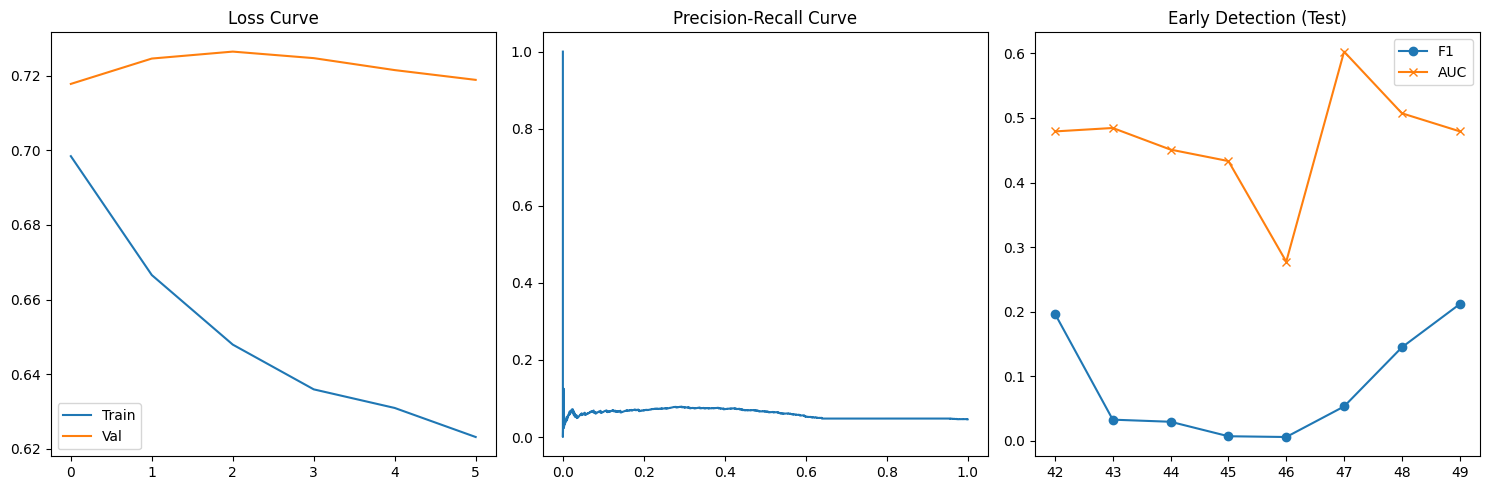

In [3]:
import torch
import torch.nn as nn
from torch_geometric.nn import TransformerConv
from torch_geometric.nn.models.tgn import TGNMemory, IdentityMessage, LastAggregator
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import time

# --- Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on device: {device}")

MEMORY_DIM = 100
TIME_DIM = 100
EMBEDDING_DIM = 100
MAX_EPOCHS = 50
PATIENCE = 5
BATCH_SIZE = 1000

# --- Model Definition ---
class GraphAttentionEmbedding(nn.Module):
    def __init__(self, in_channels, out_channels, msg_dim, time_enc):
        super().__init__()
        self.time_enc = time_enc
        edge_dim = msg_dim + time_enc.out_channels
        self.conv = TransformerConv(in_channels, out_channels // 2, heads=2,
                                    dropout=0.1, edge_dim=edge_dim)

    def forward(self, x, last_update, edge_index, t, msg):
        rel_t = t - last_update
        rel_t_emb = self.time_enc(rel_t.to(x.dtype))
        src_indices = edge_index[0]
        rel_t_emb_edges = rel_t_emb[src_indices]
        edge_attr = torch.cat([rel_t_emb_edges, msg], dim=-1)
        return self.conv(x, edge_index, edge_attr)

class TGNModel(nn.Module):
    def __init__(self, num_nodes, raw_feat_dim, memory_dim, time_dim, num_classes):
        super().__init__()
        self.num_nodes = num_nodes
        self.memory = TGNMemory(
            num_nodes=num_nodes,
            raw_msg_dim=raw_feat_dim,
            memory_dim=memory_dim,
            time_dim=time_dim,
            message_module=IdentityMessage(raw_feat_dim, memory_dim, time_dim),
            aggregator_module=LastAggregator()
        )
        self.gnn = GraphAttentionEmbedding(
            in_channels=memory_dim,
            out_channels=EMBEDDING_DIM,
            msg_dim=raw_feat_dim,
            time_enc=self.memory.time_enc,
        )
        self.mlp = nn.Sequential(
            nn.Linear(EMBEDDING_DIM, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, n_id, edge_index, edge_attr, edge_time):
        mem, last_update = self.memory(n_id)
        current_time = edge_time[0].repeat(len(n_id))
        embedding = self.gnn(mem, last_update, edge_index, current_time, edge_attr)
        out = self.mlp(embedding)
        return out

# Initialize Model
model = TGNModel(
    num_nodes=len(df_merged),
    raw_feat_dim=NUM_FEATURES,
    memory_dim=MEMORY_DIM,
    time_dim=TIME_DIM,
    num_classes=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor.to(device), ignore_index=-1)

# Convert data to Tensor (Keep on CPU to save GPU memory)
X_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)

# Helper for re-indexing
def get_local_edge_index(src, dst, nodes, device):
    assoc = torch.full((len(df_merged),), -1, dtype=torch.long, device=device)
    assoc[nodes] = torch.arange(nodes.size(0), device=device)
    return torch.stack([assoc[src], assoc[dst]], dim=0)

# Dictionary of edges by timestep
edges_by_step = {t: df_edgelist[df_edgelist['timestep'] == t] for t in range(1, 50)}

# --- Training Loop ---
print("\nStarting TGN Training...")
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(MAX_EPOCHS):
    start_time = time.time()
    model.memory.reset_state()
    
    # TRAIN (T1-T34)
    model.train()
    total_loss = 0
    batch_cnt = 0
    
    for t in range(1, 35):
        if t not in edges_by_step: continue
        step_df = edges_by_step[t]
        
        # Batching: Using full timestep as one batch here for simplicity
        src = torch.tensor(step_df['src_idx'].values, dtype=torch.long).to(device)
        dst = torch.tensor(step_df['dst_idx'].values, dtype=torch.long).to(device)
        t_tensor = torch.tensor(step_df['timestep'].values, dtype=torch.long).to(device)
        
        nodes = torch.cat([src, dst]).unique()
        edge_index_local = get_local_edge_index(src, dst, nodes, device)
        
        # Use .cpu() to index into X_tensor to avoid device mismatch errors
        batch_edge_attr = X_tensor[src.cpu()].to(device) 
        
        optimizer.zero_grad()
        logits = model(nodes, edge_index_local, batch_edge_attr, t_tensor)
        batch_y = y_tensor[nodes.cpu()].to(device)
        
        loss = loss_fn(logits, batch_y)
        loss.backward()
        optimizer.step()
        
        # Update Memory & Detach to break computation graph
        model.memory.update_state(src, dst, t_tensor, batch_edge_attr)
        model.memory.detach()
        
        total_loss += loss.item()
        batch_cnt += 1
        
    avg_train_loss = total_loss / batch_cnt
    train_losses.append(avg_train_loss)

    # VALIDATION (T35-T41) - Proxy Evaluation
    model.eval()
    val_total_loss = 0
    val_cnt = 0
    with torch.no_grad():
        for t in range(35, 42):
            if t not in edges_by_step: continue
            step_df = edges_by_step[t]
            src = torch.tensor(step_df['src_idx'].values, dtype=torch.long).to(device)
            dst = torch.tensor(step_df['dst_idx'].values, dtype=torch.long).to(device)
            t_tensor = torch.tensor(step_df['timestep'].values, dtype=torch.long).to(device)
            nodes = torch.cat([src, dst]).unique()
            
            edge_index_local = get_local_edge_index(src, dst, nodes, device)
            batch_edge_attr = X_tensor[src.cpu()].to(device)
            
            logits = model(nodes, edge_index_local, batch_edge_attr, t_tensor)
            batch_y = y_tensor[nodes.cpu()].to(device)
            
            l = loss_fn(logits, batch_y)
            val_total_loss += l.item()
            val_cnt += 1
            
            # Critical: Must update memory even during validation/test for sequentiality
            model.memory.update_state(src, dst, t_tensor, batch_edge_attr)
            
    avg_val_loss = val_total_loss / val_cnt
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {time.time()-start_time:.1f}s")
    
    # Early Stopping Check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_tgn.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered!")
            break

# --- Final Evaluation ---
print("\nRunning evaluation on Test set...")
model.load_state_dict(torch.load('best_tgn.pth'))
model.eval()
model.memory.reset_state()

# Replay Train+Val (T1-T41) to restore memory state
print("Restoring memory state (Replaying T1-T41)...")
with torch.no_grad():
    for t in range(1, 42):
        if t not in edges_by_step: continue
        step_df = edges_by_step[t]
        src = torch.tensor(step_df['src_idx'].values, dtype=torch.long).to(device)
        dst = torch.tensor(step_df['dst_idx'].values, dtype=torch.long).to(device)
        t_tensor = torch.tensor(step_df['timestep'].values, dtype=torch.long).to(device)
        batch_edge_attr = X_tensor[src.cpu()].to(device)
        model.memory.update_state(src, dst, t_tensor, batch_edge_attr)

# Test Phase (T42-T49)
print("Evaluating on T42-T49...")
all_true, all_pred, all_prob, ts_list = [], [], [], []
f1_list, auc_list = [], []

with torch.no_grad():
    for t in range(42, 50):
        if t not in edges_by_step: continue
        step_df = edges_by_step[t]
        src = torch.tensor(step_df['src_idx'].values, dtype=torch.long).to(device)
        dst = torch.tensor(step_df['dst_idx'].values, dtype=torch.long).to(device)
        t_tensor = torch.tensor(step_df['timestep'].values, dtype=torch.long).to(device)
        nodes = torch.cat([src, dst]).unique()
        
        edge_index_local = get_local_edge_index(src, dst, nodes, device)
        batch_edge_attr = X_tensor[src.cpu()].to(device)
        
        logits = model(nodes, edge_index_local, batch_edge_attr, t_tensor)
        prob = torch.softmax(logits, dim=1)[:, 1]
        pred = logits.argmax(dim=1)
        
        # Filter valid labels for metrics
        batch_y = y_tensor[nodes.cpu()].numpy()
        mask = (batch_y != -1)
        
        if mask.sum() > 0:
            y_t = batch_y[mask]
            y_p = pred.cpu().numpy()[mask]
            y_pr = prob.cpu().numpy()[mask]
            
            all_true.extend(y_t)
            all_pred.extend(y_p)
            all_prob.extend(y_pr)
            
            f1 = f1_score(y_t, y_p, pos_label=1, zero_division=0)
            try:
                auc = roc_auc_score(y_t, y_pr)
            except:
                auc = 0.5
            f1_list.append(f1)
            auc_list.append(auc)
            ts_list.append(t)
            
        model.memory.update_state(src, dst, t_tensor, batch_edge_attr)

# Report
print("\n--- FINAL TGN RESULTS ---")
print(classification_report(all_true, all_pred, target_names=['Licit', 'Illicit']))
print(f"Overall AUC: {roc_auc_score(all_true, all_prob):.4f}")
print(f"Overall AP: {average_precision_score(all_true, all_prob):.4f}")

# Plotting
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.legend(); plt.title('Loss Curve')

plt.subplot(1, 3, 2)
prec, rec, _ = precision_recall_curve(all_true, all_prob, pos_label=1)
plt.plot(rec, prec)
plt.title('Precision-Recall Curve')

plt.subplot(1, 3, 3)
plt.plot(ts_list, f1_list, marker='o', label='F1')
plt.plot(ts_list, auc_list, marker='x', label='AUC')
plt.legend(); plt.title('Early Detection (Test)')
plt.tight_layout()
plt.savefig('tgn_final_v2.png')
print("Plots saved to tgn_final_v2.png")